In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

In [3]:
import requests
import io

ЧАСТЬ 1: ПОДГОТОВКА ДАННЫХ

- Выбрать признаки для модели (8 показателей)
- Заполнить пропуски средним
- Стандартизировать данные
- Разделить на train/test (70/30, стратификация)

In [4]:
url = "https://raw.githubusercontent.com/KateAndri/StudyRepo26/main/data/dispensarization_data_2026.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

In [5]:
df.head()

,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,ССЗ_риск_высокий,Статус_глюкозы,Доклинический_риск
0,41,1,24.238237,81.037385,113.191318,62.544325,50.646993,4.595433,4.648933,NaN,NaN,1.379087,115.524101,0,165.791270,0,0,0
1,46,0,22.883365,80.539167,117.319195,62.109786,55.209410,4.963993,4.000000,2.443247,1.268905,1.902662,97.723433,0,195.027188,0,0,0
2,64,0,21.991937,78.423645,121.246690,71.456074,49.790616,4.712639,5.034903,4.212542,NaN,NaN,81.543763,0,193.198898,1,0,0
3,53,0,19.844568,73.436282,119.746372,71.594664,48.151709,4.430998,5.080881,2.267960,2.021876,1.466623,93.391224,0,248.081601,0,0,0
4,53,1,24.284829,82.062243,127.068746,70.342105,56.726641,4.996974,5.044521,2.459431,1.325116,0.967135,88.407814,0,230.452414,0,0,0


In [6]:
# 1.1 Выбор признаков для модели (8 показателей)
selected_features = [
    'Возраст',                    # Возраст пациента
    'Пол_мужской',                # Пол (1 - мужской, 0 - женский)
    'САД_мм_рт_ст',              # Систолическое АД
    'ДАД_мм_рт_ст',              # Диастолическое АД
    'Глюкоза_натощак_ммоль_л',   # Глюкоза натощак
    'ЛПНП_ммоль_л',              # Липопротеины низкой плотности
    'ЛПВП_ммоль_л',              # Липопротеины высокой плотности
    'Курение'                     # Статус курения (1 - курит, 0 - нет)
]

target = 'ССЗ_риск_высокий'

X = df[selected_features].copy()
y = df[target].copy()

print(f"\nВыбранные признаки ({len(selected_features)}): {selected_features}")
print(f"Целевая переменная: {target}")
print(f"Распределение целевой переменной:\n{y.value_counts()}")
print(f"Доля положительного класса: {y.mean():.2%}")



Выбранные признаки (8): ['Возраст', 'Пол_мужской', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст', 'Глюкоза_натощак_ммоль_л', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Курение']
Целевая переменная: ССЗ_риск_высокий
Распределение целевой переменной:
ССЗ_риск_высокий
0    819
1    181
Name: count, dtype: int64
Доля положительного класса: 18.10%


In [8]:
# 1.2 Заполнение пропусков средним
print(X.isnull().sum())

for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())  # без inplace
print(X.isnull().sum())

Возраст                    0
Пол_мужской                0
САД_мм_рт_ст               0
ДАД_мм_рт_ст               0
Глюкоза_натощак_ммоль_л    0
ЛПНП_ммоль_л               0
ЛПВП_ммоль_л               0
Курение                    0
dtype: int64
Возраст                    0
Пол_мужской                0
САД_мм_рт_ст               0
ДАД_мм_рт_ст               0
Глюкоза_натощак_ммоль_л    0
ЛПНП_ммоль_л               0
ЛПВП_ммоль_л               0
Курение                    0
dtype: int64


In [ ]:
# 1.3 Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)

In [ ]:
# 1.4 Разделение на train/test (70/30 со стратификацией)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Сохраняем баланс классов
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (700, 8)
Размер тестовой выборки: (300, 8)


ЧАСТЬ 2: ОБУЧЕНИЕ МОДЕЛИ
- Обучить SVM с RBF ядром
- Использовать class_weight='balanced'
- Включить probability=True для прогноза вероятностей
- Получить предсказания на тестовой выборке

In [ ]:
# Обучение SVM с RBF ядром
svm_model = SVC(
    kernel='rbf',           # RBF ядро
    class_weight='balanced', # Учет дисбаланса классов
    probability=True,       # Включение вероятностей
    random_state=42
)
svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

In [ ]:
# Получение предсказаний
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

print(f"\nФорма предсказаний: {y_pred.shape}")
print(f"Первые 5 вероятностей: {y_proba[:5]}")


Форма предсказаний: (300,)
Первые 5 вероятностей: [3.95648268e-04 1.75447474e-05 3.09038953e-04 1.72444500e-01
 2.69757736e-05]


ЧАСТЬ 3: ОЦЕНКА КАЧЕСТВА
- Рассчитать метрики: Accuracy, Precision, Recall, F1
- Построить матрицу ошибок
- Построить ROC-кривую с AUC
- Проанализировать 5 порогов вероятности (0.3-0.7)

In [ ]:
# 3.1 Расчет метрик
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nМетрики качества модели (при стандартном пороге 0.5):")
print(f"Accuracy (точность):  {accuracy:.4f}")
print(f"Precision (прецизионность): {precision:.4f}")
print(f"Recall (чувствительность): {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Метрики качества модели (при стандартном пороге 0.5):
Accuracy (точность):  0.9433
Precision (прецизионность): 0.7937
Recall (чувствительность): 0.9259
F1-score: 0.8547


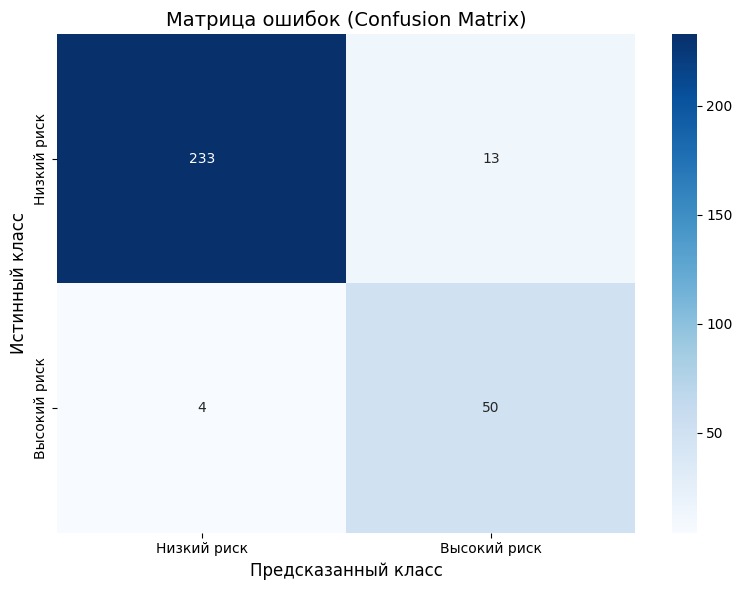

In [ ]:
# 3.2 Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Низкий риск', 'Высокий риск'],
            yticklabels=['Низкий риск', 'Высокий риск'])
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Истинный класс', fontsize=12)
plt.tight_layout()
plt.show()

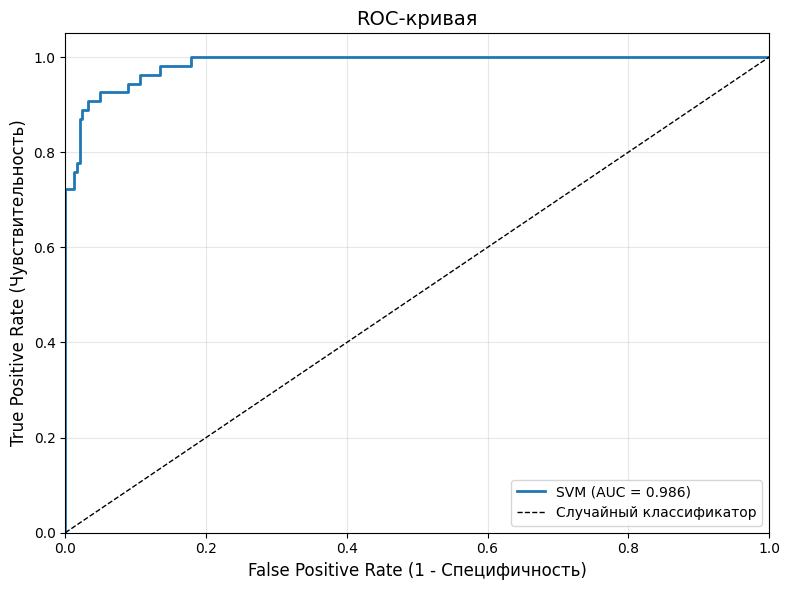


Площадь под ROC-кривой (AUC): 0.9860


In [ ]:
# 3.3 ROC-кривая с AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'SVM (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Специфичность)', fontsize=12)
plt.ylabel('True Positive Rate (Чувствительность)', fontsize=12)
plt.title('ROC-кривая', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nПлощадь под ROC-кривой (AUC): {auc:.4f}")

In [ ]:
# 3.4 Анализ 5 порогов вероятности (0.3-0.7)
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

print("\n" + "="*70)
print("Анализ различных порогов вероятности:")
print("="*70)
print(f"{'Порог':<8} {'Accuracy':<10} {'Precision':<12} {'Recall (Se)':<12} {'Specificity (Sp)':<15} {'F1':<10}")
print("-"*70)

for threshold in thresholds_to_test:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_threshold)
    prec = precision_score(y_test, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test, y_pred_threshold)

    # Расчет специфичности: TN / (TN + FP)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    f1_th = f1_score(y_test, y_pred_threshold)

    results.append({
        'threshold': threshold,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'specificity': spec,
        'f1': f1_th
    })

    print(f"{threshold:<8.1f} {acc:<10.4f} {prec:<12.4f} {rec:<12.4f} {spec:<15.4f} {f1_th:<10.4f}")



Анализ различных порогов вероятности:
Порог    Accuracy   Precision    Recall (Se)  Specificity (Sp) F1        
----------------------------------------------------------------------
0.3      0.9433     0.7937       0.9259       0.9472          0.8547    
0.4      0.9500     0.8305       0.9074       0.9593          0.8673    
0.5      0.9600     0.8889       0.8889       0.9756          0.8889    
0.6      0.9433     0.8936       0.7778       0.9797          0.8317    
0.7      0.9400     0.9286       0.7222       0.9878          0.8125    


ЧАСТЬ 4: КЛИНИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ
- Интерпретировать AUC ROC
- Объяснить чувствительность и специфичность
- Дать рекомендации по выбору порога для:
  - Массового скрининга
  - Рутинной практики
  - Подтверждения диагноза
 - Привести пример прогноза для 1 пациента

In [ ]:
print("\n1. ИНТЕРПРЕТАЦИЯ AUC ROC:")
print(f"   AUC ROC = {auc:.3f}")
if auc >= 0.9:
    print("   Отличная дискриминационная способность модели")
elif auc >= 0.8:
    print("   Хорошая дискриминационная способность модели")
elif auc >= 0.7:
    print("   Удовлетворительная дискриминационная способность модели")
else:
    print("   Низкая дискриминационная способность модели")
print("   Интерпретация: Модель хорошо разделяет пациентов с высоким и низким риском ССЗ")


1. ИНТЕРПРЕТАЦИЯ AUC ROC:
   AUC ROC = 0.986
   Отличная дискриминационная способность модели
   Интерпретация: Модель хорошо разделяет пациентов с высоким и низким риском ССЗ


ЧУВСТВИТЕЛЬНОСТЬ И СПЕЦИФИЧНОСТЬ:
- Чувствительность: способность выявлять ИСТИННО больных
(высокая чувствительность = мало ложноотрицательных результатов)

- Специфичность (Sp): способность выявлять ИСТИННО здоровых
(высокая специфичность = мало ложноположительных результатов)

In [ ]:
print("\n3. РЕКОМЕНДАЦИИ ПО ВЫБОРУ ПОРОГА:")

print("\n   А) МАССОВЫЙ СКРИНИНГ (порог 0.3-0.4):")
print("      - Характеристики при пороге 0.3:")
print(f"        * Чувствительность: {results[0]['recall']:.3f}")
print(f"        * Специфичность: {results[0]['specificity']:.3f}")
print("      - Рекомендация: Использовать низкий порог")
print("      - Цель: Не пропустить ни одного пациента с риском")
print("      - Цена ошибки: Ложноотрицательные результаты критичны")
print("      - Применение: Первичный скрининг всего населения")

print("\n   Б) РУТИННАЯ ПРАКТИКА (порог 0.5-0.6):")
best_balance = max(results[2:4], key=lambda x: x['f1'])
print(f"      - Оптимальный баланс при пороге {best_balance['threshold']:.1f}:")
print(f"        * Чувствительность: {best_balance['recall']:.3f}")
print(f"        * Специфичность: {best_balance['specificity']:.3f}")
print("      - Рекомендация: Использовать стандартный порог 0.5")
print("      - Цель: Сбалансировать выявление больных и здоровых")
print("      - Применение: Ежедневная клиническая практика")

print("\n   В) ПОДТВЕРЖДЕНИЕ ДИАГНОЗА (порог 0.7):")
print(f"      - Характеристики при пороге 0.7:")
print(f"        * Чувствительность: {results[4]['recall']:.3f}")
print(f"        * Специфичность: {results[4]['specificity']:.3f}")
print("      - Рекомендация: Использовать высокий порог")
print("      - Цель: Избежать гипердиагностики")
print("      - Цена ошибки: Ложноположительные результаты критичны")
print("      - Применение: Назначение дорогостоящего/рискованного лечения")


3. РЕКОМЕНДАЦИИ ПО ВЫБОРУ ПОРОГА:

   А) МАССОВЫЙ СКРИНИНГ (порог 0.3-0.4):
      - Характеристики при пороге 0.3:
        * Чувствительность: 0.926
        * Специфичность: 0.947
      - Рекомендация: Использовать низкий порог
      - Цель: Не пропустить ни одного пациента с риском
      - Цена ошибки: Ложноотрицательные результаты критичны
      - Применение: Первичный скрининг всего населения

   Б) РУТИННАЯ ПРАКТИКА (порог 0.5-0.6):
      - Оптимальный баланс при пороге 0.5:
        * Чувствительность: 0.889
        * Специфичность: 0.976
      - Рекомендация: Использовать стандартный порог 0.5
      - Цель: Сбалансировать выявление больных и здоровых
      - Применение: Ежедневная клиническая практика

   В) ПОДТВЕРЖДЕНИЕ ДИАГНОЗА (порог 0.7):
      - Характеристики при пороге 0.7:
        * Чувствительность: 0.722
        * Специфичность: 0.988
      - Рекомендация: Использовать высокий порог
      - Цель: Избежать гипердиагностики
      - Цена ошибки: Ложноположительные результ

In [ ]:
# 4.4 Пример прогноза для 1 пациента
print("\n4. ПРИМЕР ПРОГНОЗА ДЛЯ 1 ПАЦИЕНТА:")
sample_idx = 0
sample_features = X_test.iloc[sample_idx:sample_idx+1]
sample_true_label = y_test.iloc[sample_idx]
sample_proba = svm_model.predict_proba(sample_features)[0][1]
sample_pred = svm_model.predict(sample_features)[0]

print(f"\n   Данные пациента (стандартизированные):")
for i, col in enumerate(selected_features):
    print(f"   {col}: {sample_features.iloc[0, i]:.3f}")

print(f"\n   Истинный риск: {'ВЫСОКИЙ' if sample_true_label == 1 else 'НИЗКИЙ'}")
print(f"   Вероятность высокого риска: {sample_proba:.3f}")
print(f"   Предсказанный риск: {'ВЫСОКИЙ' if sample_pred == 1 else 'НИЗКИЙ'}")


4. ПРИМЕР ПРОГНОЗА ДЛЯ 1 ПАЦИЕНТА:

   Данные пациента (стандартизированные):
   Возраст: -0.447
   Пол_мужской: -0.890
   САД_мм_рт_ст: 0.576
   ДАД_мм_рт_ст: -0.642
   Глюкоза_натощак_ммоль_л: -0.161
   ЛПНП_ммоль_л: -1.984
   ЛПВП_ммоль_л: -0.210
   Курение: -0.619

   Истинный риск: НИЗКИЙ
   Вероятность высокого риска: 0.000
   Предсказанный риск: НИЗКИЙ
